In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import src.data_loader
import src.features
import src.train

importlib.reload(src.data_loader)
importlib.reload(src.features)
importlib.reload(src.train)

from src.data_loader import fetch_dam_prices, load_prices, save_prices
from src.features import (
    build_supervised_dataset,
    make_calendar_features,
    make_forecast_time_features,
    make_target_relative_lags,
    hours_to_target,
)
from src.train import train_per_horizon_models, predict_next_day

print("Imports OK.")

Imports OK.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)
token = os.getenv("ENTSOE_API_TOKEN")

if token:
    print(f"Token loaded ✓  (length: {len(token)}, prefix: {token[:6]}…)")
else:
    raise RuntimeError(
        "ENTSOE_API_TOKEN not found. Check that .env exists in the project "
        "root and contains the line: ENTSOE_API_TOKEN=your_token"
    )

Token loaded ✓  (length: 36, prefix: e66909…)


In [3]:
# Pull a short period first to fail fast if anything is wrong
test_start = pd.Timestamp("2024-06-01", tz="Europe/Athens")
test_end = pd.Timestamp("2024-06-08", tz="Europe/Athens")

prices_test = fetch_dam_prices(test_start, test_end, country_code="GR")
print(f"Fetched {len(prices_test)} hourly prices.")
print(f"Range: {prices_test.index.min()}  →  {prices_test.index.max()}")
print(f"Mean:  {prices_test.mean():.2f} EUR/MWh")
print(f"Range: {prices_test.min():.2f} … {prices_test.max():.2f}")
prices_test.head()

Fetched 169 hourly prices.
Range: 2024-06-01 00:00:00+03:00  →  2024-06-08 00:00:00+03:00
Mean:  95.69 EUR/MWh
Range: 0.04 … 229.44


2024-06-01 00:00:00+03:00    93.25
2024-06-01 01:00:00+03:00    86.20
2024-06-01 02:00:00+03:00    81.89
2024-06-01 03:00:00+03:00    74.55
2024-06-01 04:00:00+03:00    75.73
Freq: h, Name: price_eur_mwh, dtype: float64

In [3]:
CACHE_PATH = Path("../data/raw/greek_inputs_2023_2024H1.csv")
DATA_START = pd.Timestamp("2023-01-01", tz="Europe/Athens")
DATA_END = pd.Timestamp("2024-07-01", tz="Europe/Athens")

if CACHE_PATH.exists():
    inputs_raw = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True)
    print(f"Loaded {len(inputs_raw)} rows from cache.")
else:
    print("Cache not found, fetching from ENTSO-E (may take 1-2 minutes)…")
    from src.data_loader import fetch_all_inputs
    inputs_raw = fetch_all_inputs(DATA_START, DATA_END, country_code="GR")
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    inputs_raw.to_csv(CACHE_PATH)
    print(f"Fetched and cached {len(inputs_raw)} rows to {CACHE_PATH}")

print(f"\nColumns: {list(inputs_raw.columns)}")
print(f"Range: {inputs_raw.index.min()} → {inputs_raw.index.max()}")
print(f"\nSample:")
inputs_raw.head()

Cache not found, fetching from ENTSO-E (may take 1-2 minutes)…
Fetched and cached 13128 rows to ..\data\raw\greek_inputs_2023_2024H1.csv

Columns: ['price_eur_mwh', 'load_forecast_mw', 'solar', 'wind_onshore']
Range: 2023-01-01 00:00:00+02:00 → 2024-07-01 00:00:00+03:00

Sample:


,price_eur_mwh,load_forecast_mw,solar,wind_onshore
2023-01-01 00:00:00+02:00,210.05,4269.0,0.0,495.0
2023-01-01 01:00:00+02:00,230.90,4008.0,0.0,518.0
2023-01-01 02:00:00+02:00,268.19,3888.0,0.0,560.0
2023-01-01 03:00:00+02:00,229.58,3760.0,0.0,603.0
2023-01-01 04:00:00+02:00,235.98,3703.0,0.0,649.0


In [ ]:
# Split inputs into price (target) and exog (features)
exog_cols = [c for c in inputs.columns if c != "price_eur_mwh"]
exog = inputs[exog_cols].copy()

print(f"Exog columns: {list(exog.columns)}")
print(f"Exog shape: {exog.shape}")
print()
print(exog.describe().T)

price_eur_mwh       0
load_forecast_mw    2
solar               2
wind_onshore        2
dtype: int64

In [5]:
# Inspect missing values per column
print("Missing values per column:")
print(inputs_raw.isna().sum())

# Forward-fill all columns to handle short gaps
inputs = inputs_raw.ffill()

# Pull out the price series for backwards compatibility with cells below
prices = inputs["price_eur_mwh"].copy()

print(f"\nAfter ffill — missing values:")
print(inputs.isna().sum())

Missing values per column:
price_eur_mwh       0
load_forecast_mw    2
solar               2
wind_onshore        2
dtype: int64

After ffill — missing values:
price_eur_mwh       0
load_forecast_mw    0
solar               0
wind_onshore        0
dtype: int64


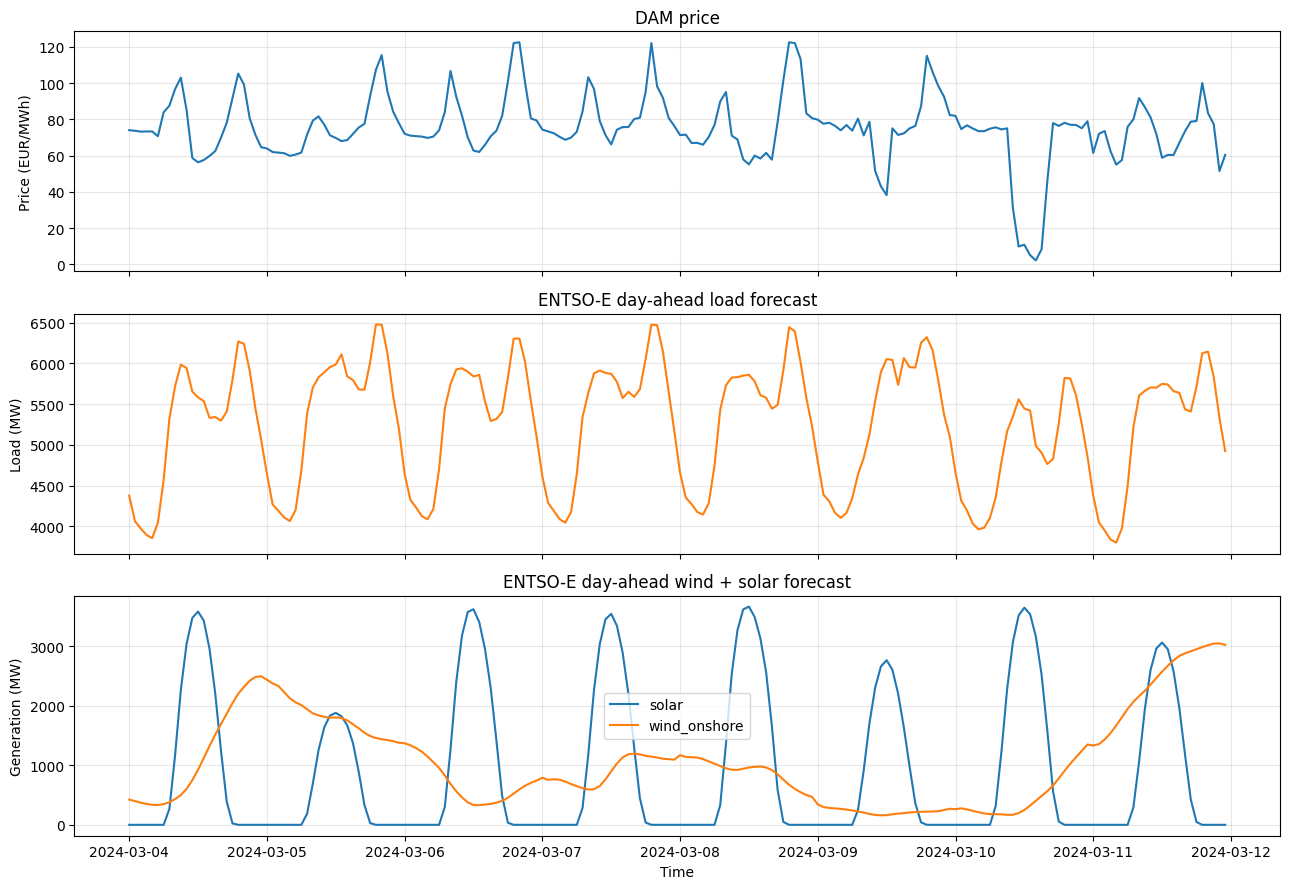

In [6]:
# Plot price, load, and renewable forecasts on the same timeline
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

window = inputs.loc["2024-03-04":"2024-03-11"]

axes[0].plot(window.index, window["price_eur_mwh"], color="C0")
axes[0].set_ylabel("Price (EUR/MWh)")
axes[0].set_title("DAM price")
axes[0].grid(alpha=0.3)

axes[1].plot(window.index, window["load_forecast_mw"], color="C1")
axes[1].set_ylabel("Load (MW)")
axes[1].set_title("ENTSO-E day-ahead load forecast")
axes[1].grid(alpha=0.3)

# Stack renewables
renew_cols = [c for c in window.columns if c not in ("price_eur_mwh", "load_forecast_mw")]
for c in renew_cols:
    axes[2].plot(window.index, window[c], label=c)
axes[2].set_ylabel("Generation (MW)")
axes[2].set_title("ENTSO-E day-ahead wind + solar forecast")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
nan_idx = prices_raw[prices_raw.isna()].index
print(f"Total NaN rows: {len(nan_idx)}")
if len(nan_idx) > 0:
    print("First 10 NaN timestamps:")
    for ts in nan_idx[:10]:
        print(f"  {ts}")

# Forward-fill short gaps. For longer gaps, you'd want a more careful policy
# (interpolation, or refuse to use that data). For now, ffill is reasonable.
prices = prices_raw.ffill()

print(f"\nNaN after ffill: {prices.isna().sum()}")
print(f"Total rows: {len(prices)}")

Total NaN rows: 0

NaN after ffill: 0
Total rows: 13128


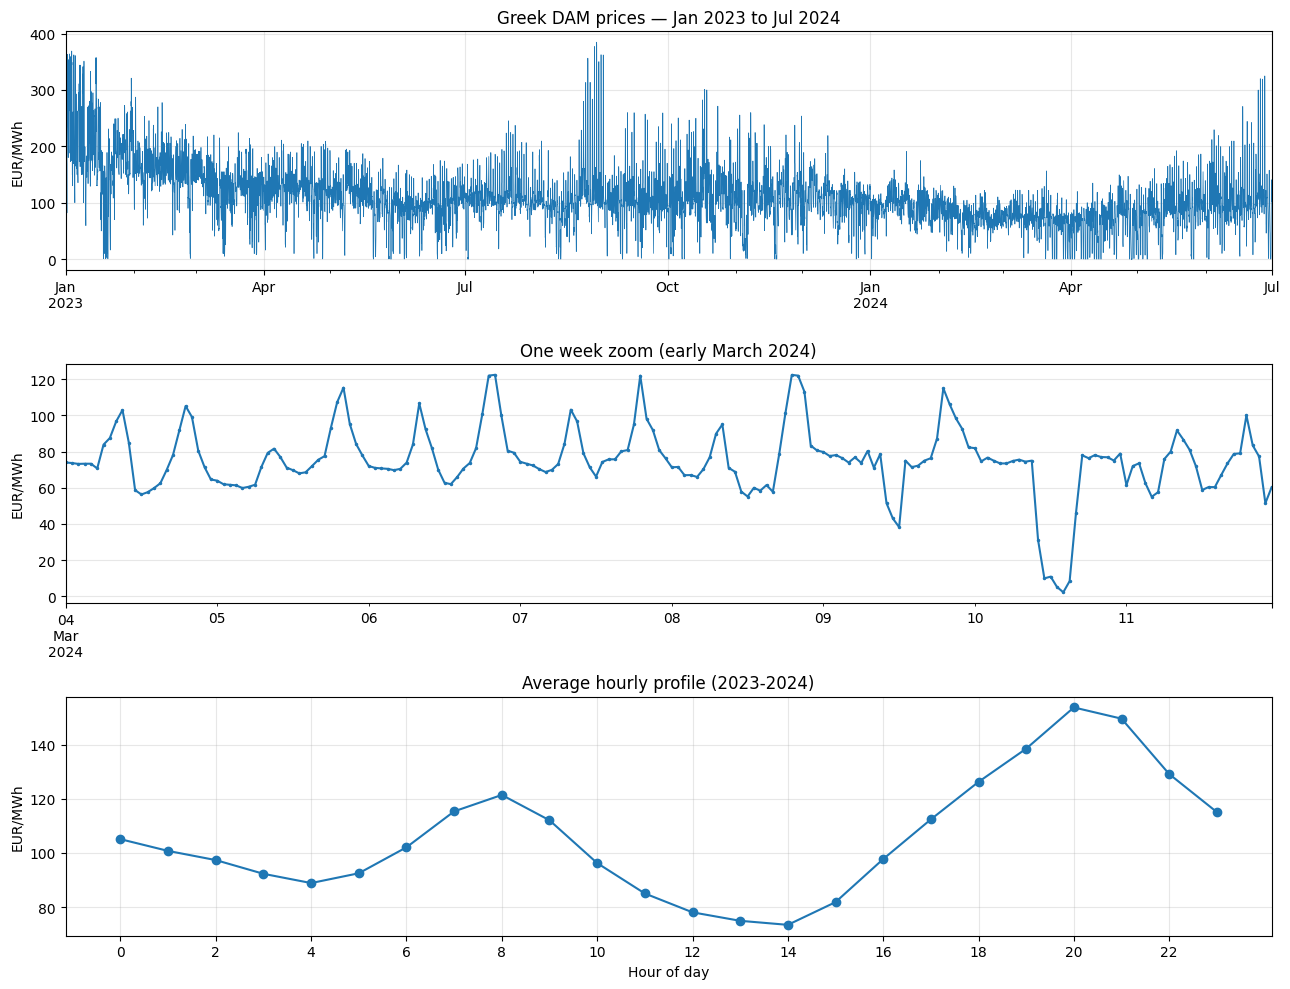

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Full history
prices.plot(ax=axes[0], title="Greek DAM prices — Jan 2023 to Jul 2024", linewidth=0.5)
axes[0].set_ylabel("EUR/MWh")
axes[0].grid(alpha=0.3)

# One typical week
week = prices.loc["2024-03-04":"2024-03-11"]
week.plot(ax=axes[1], title="One week zoom (early March 2024)", marker=".", markersize=3)
axes[1].set_ylabel("EUR/MWh")
axes[1].grid(alpha=0.3)

# Average daily profile
hourly_avg = prices.groupby(prices.index.hour).mean()
hourly_avg.plot(ax=axes[2], marker="o", title="Average hourly profile (2023-2024)")
axes[2].set_ylabel("EUR/MWh")
axes[2].set_xlabel("Hour of day")
axes[2].set_xticks(range(0, 24, 2))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
GATE_CLOSURE_HOUR = 12
HORIZONS = tuple(range(0, 24))   # tomorrow's full 24 hours
SAME_HOUR_LAG_DAYS = (1, 2, 7)
CONTEXT_WINDOW = 1
TEST_DAYS = 30                    # bigger test window for real data

X, y, meta = build_supervised_dataset(
    prices,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Forecast days: {meta['forecast_time'].nunique()}")
print(f"Horizons: {meta['horizon'].nunique()} ({meta['horizon'].min()}–{meta['horizon'].max()})")

X shape: (13105, 31)
y shape: (13105,)
Forecast days: 547
Horizons: 24 (0–23)


In [11]:
print("NaN pattern in tr_* features by horizon (after warm-up).\n")
print(f"{'horizon':>7} | {'NaN tr_* columns':<55} | n_NaN")
print("-" * 80)

tr_cols = [c for c in X.columns if c.startswith("tr_")]

for h in sorted(meta["horizon"].unique()):
    mask = (meta["horizon"] == h)
    rows_for_h = X[mask].reset_index(drop=True)
    sample = rows_for_h.iloc[10]   # past warm-up
    nan_cols = [c for c in tr_cols if pd.isna(sample[c])]
    label = ", ".join(c.replace("tr_lag_", "") for c in nan_cols) or "(none)"
    print(f"{h:>7} | {label:<55} | {len(nan_cols)}")

NaN pattern in tr_* features by horizon (after warm-up).

horizon | NaN tr_* columns                                        | n_NaN
--------------------------------------------------------------------------------
      0 | (none)                                                  | 0
      1 | (none)                                                  | 0
      2 | (none)                                                  | 0
      3 | (none)                                                  | 0
      4 | (none)                                                  | 0
      5 | (none)                                                  | 0
      6 | (none)                                                  | 0
      7 | (none)                                                  | 0
      8 | (none)                                                  | 0
      9 | (none)                                                  | 0
     10 | (none)                                                  | 0
     11 | (none) 

In [12]:
result = train_per_horizon_models(
    prices,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
    test_days=TEST_DAYS,
)

print(f"Trained {len(result.models)} per-horizon models.")
print(f"Overall test MAE:  {result.overall_test_mae:.2f} EUR/MWh")
print(f"Overall test RMSE: {result.overall_test_rmse:.2f} EUR/MWh")

Trained 24 per-horizon models.
Overall test MAE:  21.52 EUR/MWh
Overall test RMSE: 27.51 EUR/MWh


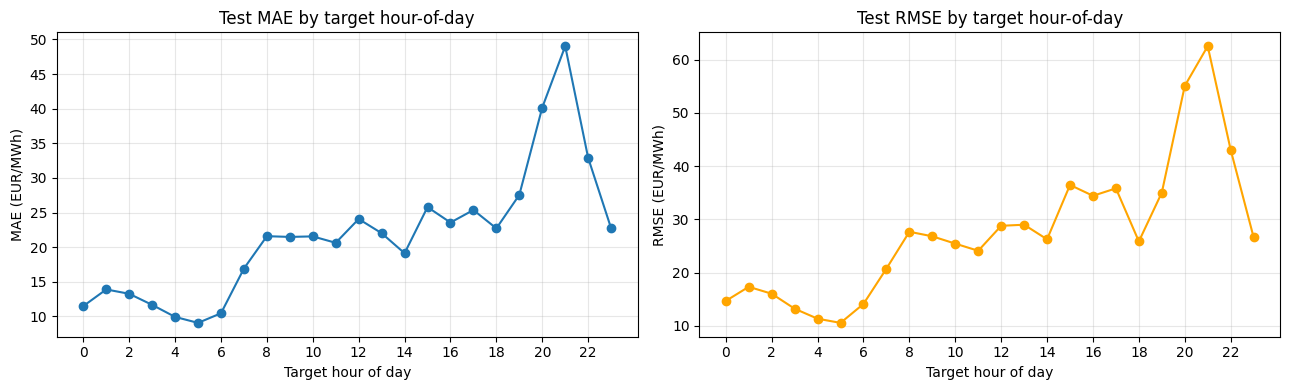

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

result.metrics_per_horizon.plot(
    x="horizon", y="mae", marker="o", ax=axes[0], legend=False
)
axes[0].set_title("Test MAE by target hour-of-day")
axes[0].set_ylabel("MAE (EUR/MWh)")
axes[0].set_xlabel("Target hour of day")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.3)

result.metrics_per_horizon.plot(
    x="horizon", y="rmse", marker="o", color="orange", ax=axes[1], legend=False
)
axes[1].set_title("Test RMSE by target hour-of-day")
axes[1].set_ylabel("RMSE (EUR/MWh)")
axes[1].set_xlabel("Target hour of day")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Peak hours (8, 19-20) often have the highest error in absolute terms — they're the most volatile


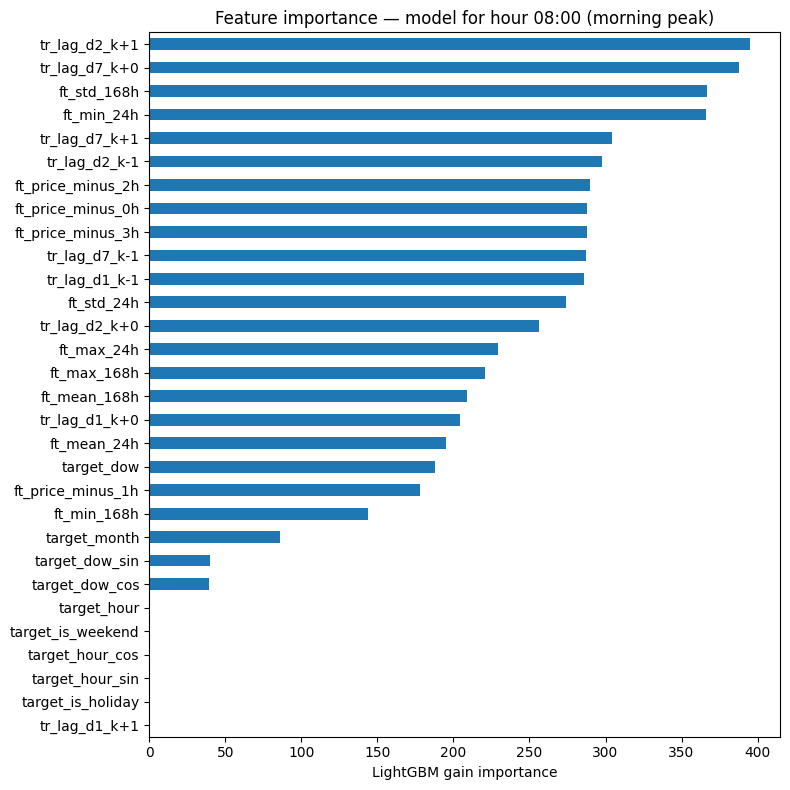

In [14]:
model_h8 = result.models[8]   # the model that predicts tomorrow 08:00 (morning peak)
importances = pd.Series(
    model_h8.feature_importances_,
    index=result.feature_names,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot.barh(ax=ax)
ax.set_title("Feature importance — model for hour 08:00 (morning peak)")
ax.set_xlabel("LightGBM gain importance")
plt.tight_layout()
plt.show()

Overall test MAE by gate closure hour:
  gc=11 → 22.39
  gc=12 → 21.52
  gc=17 → 21.92



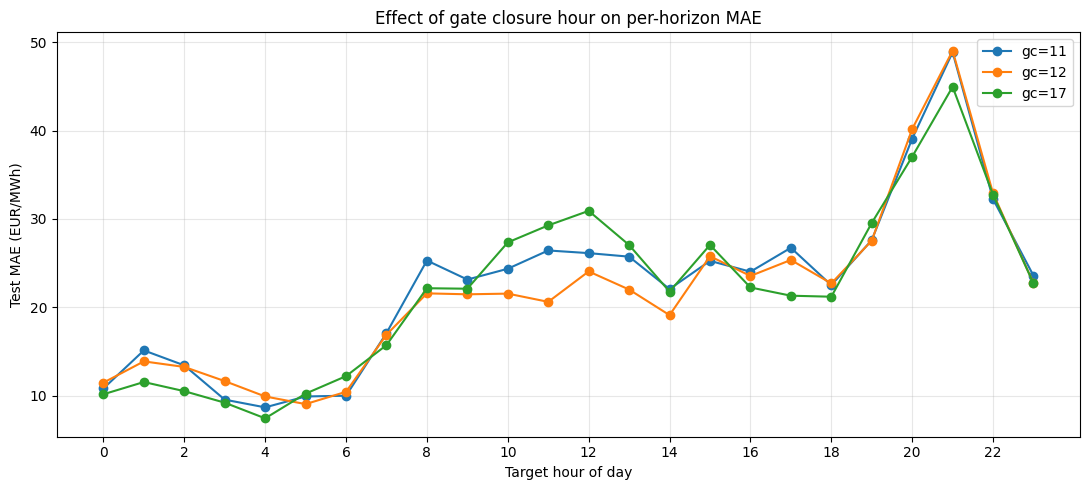

In [15]:
# Train two more variants to see how gate_closure_hour affects accuracy
result_11 = train_per_horizon_models(
    prices,
    gate_closure_hour=11,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
    test_days=TEST_DAYS,
)

result_17 = train_per_horizon_models(
    prices,
    gate_closure_hour=17,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
    test_days=TEST_DAYS,
)

print(f"Overall test MAE by gate closure hour:")
print(f"  gc=11 → {result_11.overall_test_mae:.2f}")
print(f"  gc=12 → {result.overall_test_mae:.2f}")
print(f"  gc=17 → {result_17.overall_test_mae:.2f}")
print()

comp = pd.DataFrame({
    "gc=11": result_11.metrics_per_horizon.set_index("horizon")["mae"],
    "gc=12": result.metrics_per_horizon.set_index("horizon")["mae"],
    "gc=17": result_17.metrics_per_horizon.set_index("horizon")["mae"],
})

fig, ax = plt.subplots(figsize=(11, 5))
comp.plot(ax=ax, marker="o")
ax.set_title("Effect of gate closure hour on per-horizon MAE")
ax.set_ylabel("Test MAE (EUR/MWh)")
ax.set_xlabel("Target hour of day")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
import importlib
import src.baselines
importlib.reload(src.baselines)
from src.baselines import evaluate_naive_baselines

# Reproduce the same train/test split that train_per_horizon_models used
from src.train import temporal_split

X_full, y_full, meta_full = build_supervised_dataset(
    prices,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
)
_, _, _, X_te, y_te, m_te = temporal_split(X_full, y_full, meta_full, test_days=TEST_DAYS)

naive_metrics = evaluate_naive_baselines(
    prices, m_te, y_te, gate_closure_hour=GATE_CLOSURE_HOUR
)

print("Naïve baselines per-horizon test MAE:\n")
print(naive_metrics[["horizon", "mae_yesterday", "mae_last_week", "mae_average", "n_test"]].to_string(index=False))

print()
print(f"Naïve overall MAE (weighted by n_test):")
weights = naive_metrics["n_test"]
for col in ["mae_yesterday", "mae_last_week", "mae_average"]:
    overall = (naive_metrics[col] * weights).sum() / weights.sum()
    print(f"  {col:20s} = {overall:.2f}")
print()
print(f"LightGBM model overall MAE: {result.overall_test_mae:.2f}")

Naïve baselines per-horizon test MAE:

 horizon  mae_yesterday  mae_last_week  mae_average  n_test
       0      11.095333      13.022000     9.845333      30
       1      14.515517      14.621379    11.385000      29
       2      12.715172      14.961724    11.323621      29
       3       9.627241      10.654483     8.359483      29
       4       9.071379       8.507586     8.003621      29
       5      10.357241      10.389655     9.575172      29
       6      10.225172      12.507241    10.151379      29
       7      21.108966      19.066897    17.872069      29
       8      31.838621      29.583448    24.748966      29
       9      27.071724      19.357241    19.896552      29
      10      23.502759      21.782069    21.206552      29
      11      24.780690      17.124138    18.732414      29
      12      23.503103      16.896552    18.553621      29
      13      35.109655      21.056897    25.511207      29
      14      36.787586      23.539310    26.328966      29
 

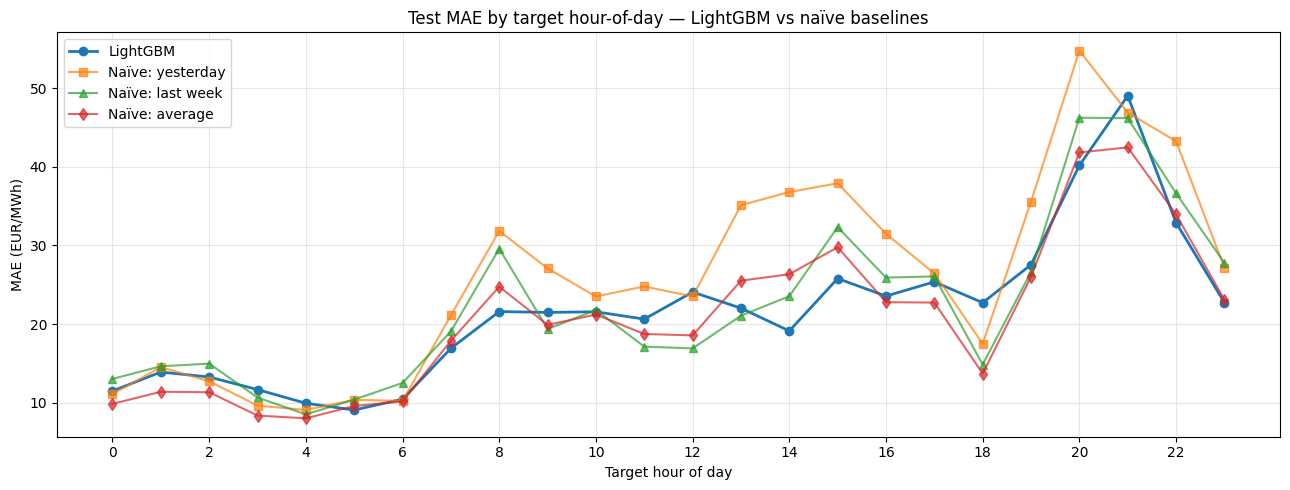

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))

# LightGBM model
lgbm_metrics = result.metrics_per_horizon.set_index("horizon")
ax.plot(lgbm_metrics.index, lgbm_metrics["mae"], marker="o", label="LightGBM", linewidth=2)

# Naïve baselines
naive_indexed = naive_metrics.set_index("horizon")
ax.plot(naive_indexed.index, naive_indexed["mae_yesterday"], marker="s", label="Naïve: yesterday", alpha=0.7)
ax.plot(naive_indexed.index, naive_indexed["mae_last_week"], marker="^", label="Naïve: last week", alpha=0.7)
ax.plot(naive_indexed.index, naive_indexed["mae_average"], marker="d", label="Naïve: average", alpha=0.7)

ax.set_title("Test MAE by target hour-of-day — LightGBM vs naïve baselines")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_xlabel("Target hour of day")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
print("=" * 60)
print(" Summary: LightGBM vs naïve baselines (overall test MAE)")
print("=" * 60)
print(f" LightGBM:         {result.overall_test_mae:7.2f} EUR/MWh")

weights = naive_metrics["n_test"]
for col, label in [
    ("mae_yesterday",  "Naïve yesterday "),
    ("mae_last_week",  "Naïve last week "),
    ("mae_average",    "Naïve average  "),
]:
    naive_mae = (naive_metrics[col] * weights).sum() / weights.sum()
    delta = naive_mae - result.overall_test_mae   # positive => LGBM is better
    pct = 100 * delta / naive_mae
    direction = "better" if delta > 0 else "WORSE"
    print(f" {label}: {naive_mae:7.2f}   (LightGBM is {pct:+.1f}% {direction})")
print("=" * 60)

 Summary: LightGBM vs naïve baselines (overall test MAE)
 LightGBM:           21.52 EUR/MWh
 Naïve yesterday :   25.91   (LightGBM is +16.9% better)
 Naïve last week :   22.30   (LightGBM is +3.5% better)
 Naïve average  :   20.72   (LightGBM is -3.8% WORSE)
